In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
# https://www.kaggle.com/datasets/shwetabh123/mall-customers

df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [5]:
import math
def plot_all_histogram(df, title_prefix=""):
    num_cols = df.select_dtypes(include=[np.number]).columns
    n_cols = 3
    n_rows = math.ceil(len(num_cols) / n_cols)

    plt.figure(figsize = (5 * n_cols, 4 * n_rows))

    for i, col in enumerate(num_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f"{title_prefix} {col}")
        plt.xlabel("")
        plt.ylabel("")

    plt.tight_layout()
    plt.show()

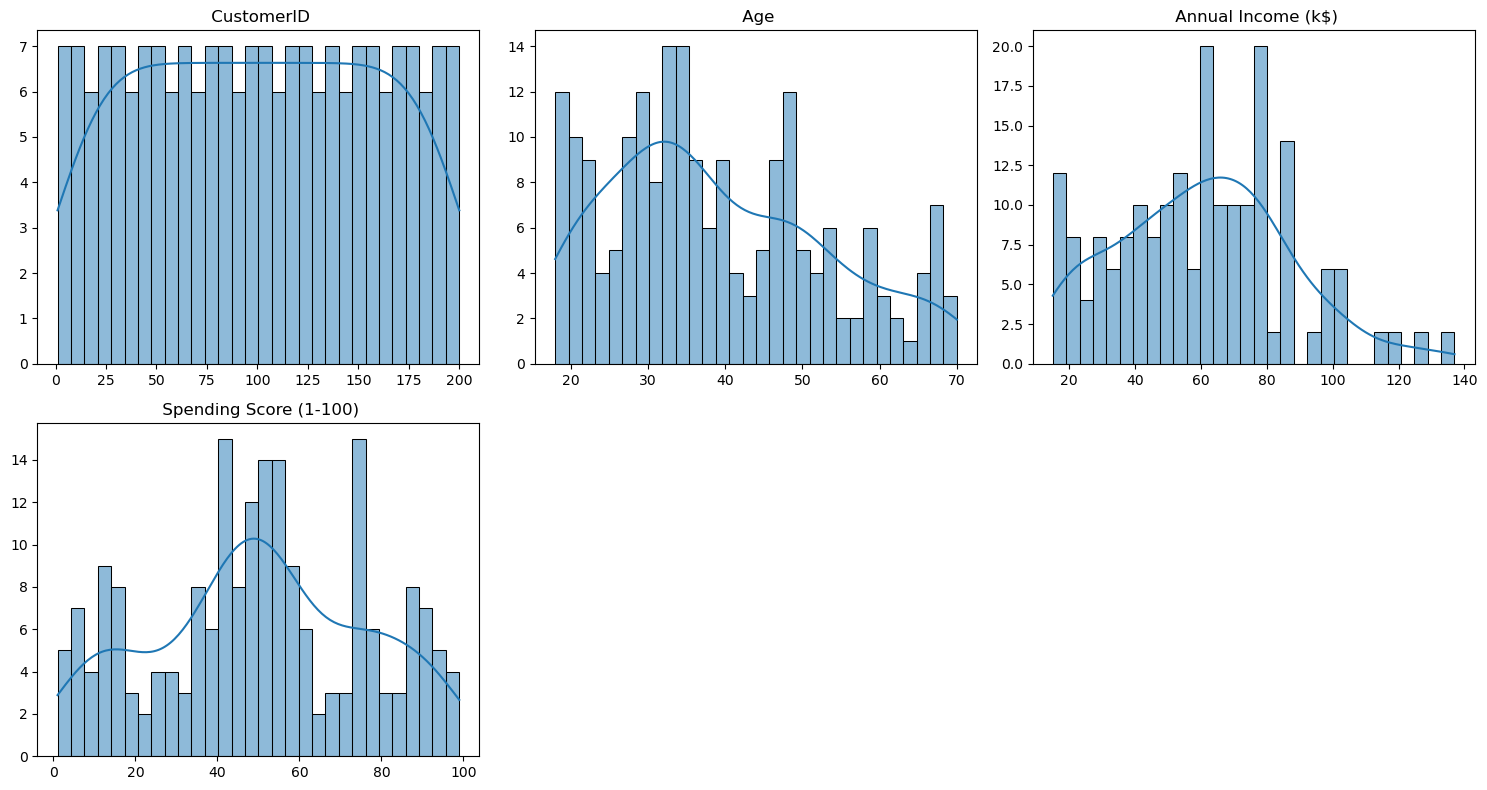

In [6]:
plot_all_histogram(df)

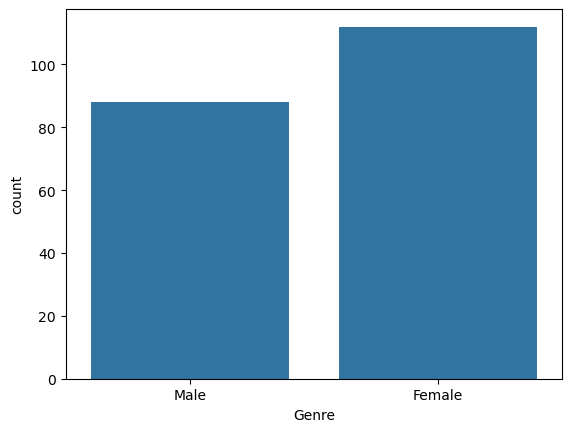

In [7]:
sns.countplot(data = df, x = "Genre") # gender 
plt.show()

In [8]:
from sklearn.preprocessing import LabelEncoder

label = LabelEncoder()

# male -> 1, female -> 0
df["Genre"] = label.fit_transform(df["Genre"])

df = df.drop("CustomerID", axis = 1)

df.head()

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [9]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_scaled = scaler.fit_transform(df)

In [10]:
df = pd.DataFrame(df_scaled, columns=df.columns)
df.head()

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1.0,0.019231,0.000000,0.387755
1,1.0,0.057692,0.000000,0.816327
2,0.0,0.038462,0.008197,0.051020
3,0.0,0.096154,0.008197,0.775510
4,0.0,0.250000,0.016393,0.397959


In [11]:
# Dendrogram Çizmek
# https://scikit-learn.org/stable/auto_examples/cluster/plot_linkage_comparison.html#sphx-glr-auto-examples-cluster-plot-linkage-comparison-py
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html#scipy.cluster.hierarchy.linkage

import scipy.cluster.hierarchy as sch

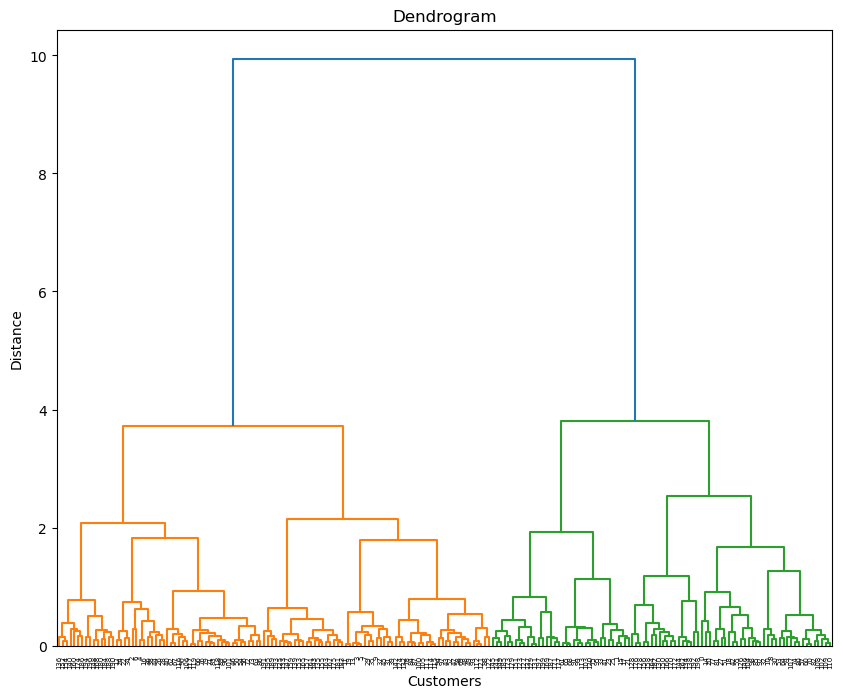

In [12]:
plt.figure(1, figsize=(10,8))
dendrogram = sch.dendrogram(sch.linkage(df, method="ward"))
plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

In [13]:
# we can clearly select 4 to 6 clusters from this dendrogram, let's go for 4

In [14]:
from sklearn.cluster import AgglomerativeClustering

In [15]:
hc = AgglomerativeClustering(n_clusters=4)

In [16]:
y_hc = hc.fit_predict(df)

In [17]:
df["cluster"] = pd.DataFrame(y_hc)
df.head()

,Genre,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1.0,0.019231,0.000000,0.387755,0
1,1.0,0.057692,0.000000,0.816327,2
2,0.0,0.038462,0.008197,0.051020,3
3,0.0,0.096154,0.008197,0.775510,1
4,0.0,0.250000,0.016393,0.397959,3


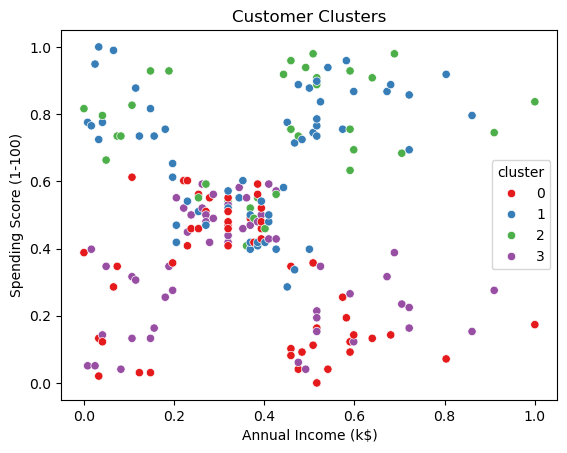

In [18]:
sns.scatterplot(data = df, x = "Annual Income (k$)", y = "Spending Score (1-100)", hue = "cluster", palette="Set1")
plt.title("Customer Clusters")
plt.show()

In [19]:
from sklearn.metrics import silhouette_score

score = silhouette_score(df, y_hc)
print(score)

0.7143503785893516


In [20]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]].copy()
X.head()

,Annual Income (k$),Spending Score (1-100)
0,0.000000,0.387755
1,0.000000,0.816327
2,0.008197,0.051020
3,0.008197,0.775510
4,0.016393,0.397959


In [21]:
hc = AgglomerativeClustering(n_clusters=5)
y_hc = hc.fit_predict(X)
X["cluster"] = y_hc

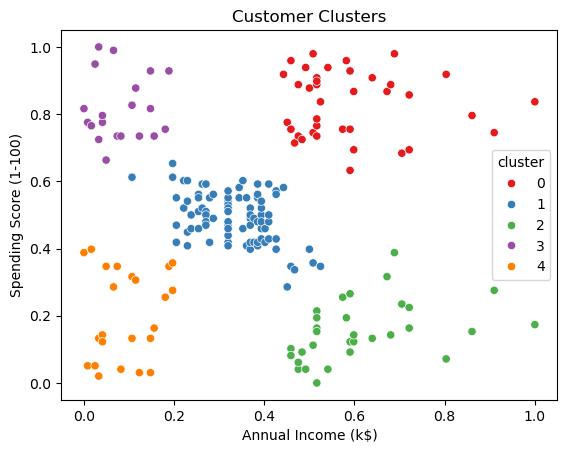

In [22]:
sns.scatterplot(data = X, x = "Annual Income (k$)", y = "Spending Score (1-100)", hue = "cluster", palette="Set1")
plt.title("Customer Clusters")
plt.show()

In [23]:
score = silhouette_score(X, y_hc)
print(score)

0.8508773413981672


In [24]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

In [25]:
df = pd.read_csv("Mall_Customers.csv")
df = df.drop("CustomerID", axis=1)
le = LabelEncoder()
df["Genre"] = le.fit_transform(df["Genre"])

features_2d = ["Annual Income (k$)", "Spending Score (1-100)"]
features_3d = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
features_4d = ["Genre", "Age", "Annual Income (k$)", "Spending Score (1-100)"]

for feats in [features_2d, features_3d, features_4d]:
    X = df[feats]
    X_scaled = MinMaxScaler().fit_transform(X)

    hc = AgglomerativeClustering(n_clusters=5)
    y_hc = hc.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, y_hc)
    chs = calinski_harabasz_score(X_scaled, y_hc)
    dbs = davies_bouldin_score(X_scaled, y_hc)

    print(f"\nfeatures: {feats}")
    print("Silhoutte Score:", sil)
    print("Davies Bouldin Score", dbs)
    print("Calinski Harabasz Score:", chs)
    print("-" * 50)


features: ['Annual Income (k$)', 'Spending Score (1-100)']
Silhoutte Score: 0.5582698727196419
Davies Bouldin Score 0.5734519252471811
Calinski Harabasz Score: 258.97400737720704
--------------------------------------------------

features: ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Silhoutte Score: 0.3955454334726547
Davies Bouldin Score 0.8746143334035464
Calinski Harabasz Score: 123.99070840826577
--------------------------------------------------

features: ['Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Silhoutte Score: 0.35032447507156306
Davies Bouldin Score 1.0941951795238571
Calinski Harabasz Score: 163.46602356383625
--------------------------------------------------


In [26]:
from sklearn.cluster import KMeans

df = pd.read_csv("Mall_Customers.csv")
df = df.drop("CustomerID", axis=1)
le = LabelEncoder()
df["Genre"] = le.fit_transform(df["Genre"])

features_2d = ["Annual Income (k$)", "Spending Score (1-100)"]
features_3d = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
features_4d = ["Genre", "Age", "Annual Income (k$)", "Spending Score (1-100)"]

for feats in [features_2d, features_3d, features_4d]:
    X = df[feats]
    X_scaled = MinMaxScaler().fit_transform(X)

    kmeans = KMeans(n_clusters=5)
    y_hc = kmeans.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, y_hc)
    chs = calinski_harabasz_score(X_scaled, y_hc)
    dbs = davies_bouldin_score(X_scaled, y_hc)

    print(f"\nfeatures: {feats}")
    print("Silhoutte Score:", sil)
    print("Davies Bouldin Score", dbs)
    print("Calinski Harabasz Score:", chs)
    print("-" * 50)


features: ['Annual Income (k$)', 'Spending Score (1-100)']
Silhoutte Score: 0.5593469429051445
Davies Bouldin Score 0.5616471225010365
Calinski Harabasz Score: 264.5506476775084
--------------------------------------------------

features: ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Silhoutte Score: 0.37358956496553747
Davies Bouldin Score 1.0781573346216926
Calinski Harabasz Score: 120.01508296629964
--------------------------------------------------

features: ['Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Silhoutte Score: 0.37089464698896935
Davies Bouldin Score 0.9954096267348429
Calinski Harabasz Score: 172.92326859199304
--------------------------------------------------


D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
